# Non-Stationary Risk and Return Period

Modeling Generalized Extreme Value (GEV) Distribution

In this example, we will import a precipitation **Annual Maxima Series (AMS)** for a **60-minute duration**, extracted from a continuous rainfall record available at **15-minute resolution** from the COOP station **USC00092485** located in **Georgia, USA**.

- The **station metadata** are available in the file: `station_metadata.json`.
- The **annual maxima series**, covering the period **1975–2024** (50 years of record), is provided in the file: `Annual_maxima_series.csv`.

> **Note:** The AMS values are real observations from the station. However, the climate covariates used in this analysis (e.g., temperature anomaly and north atlantic oscillation (NAO) index) are **synthetically generated** for demonstration purposes.

We will explore the relationship between extreme rainfall and climate covariates, and fit a non-stationary GEV model using selected covariates.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown
from scipy.stats import genextreme

import nsEVDx as ns

#### Loading/Plotting AMS and Covariates

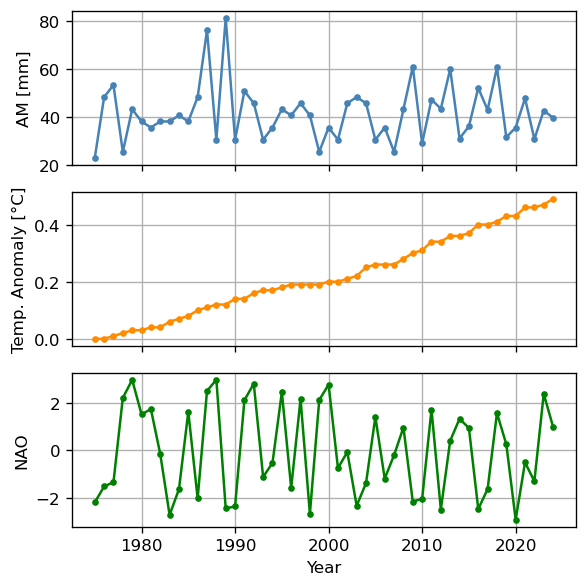

In [2]:
# Annual maxima series
AMS_df = pd.read_csv("data/Annual_maxima_series.csv", index_col=0)

# Covariates
cov_df = pd.read_csv("data/temp_anomaly_&_NAO.csv", index_col=0)

# Merge dataframes on 'year'
df = pd.merge(AMS_df, cov_df, on="year")

# Variables to plot
variables = ["60_min_maxima", "temp_anomaly", "NAO"]
titles = ["AM [mm]", "Temp. Anomaly [°C]", "NAO"]
colors = ["steelblue", "darkorange", "green"]

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(5, 5), sharex=True, dpi=120)
for i, var in enumerate(variables):
    axs[i].plot(df["year"], df[var], color=colors[i], marker=".")
    axs[i].set_ylabel(titles[i])
    axs[i].grid(True)

axs[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()

#### Preparing Covariates and AMS data for Non-Stationary GEV Sampler

To model a non-stationary GEV distribution, we must prepare the **covariate matrix** including **time vector** in a format compatible with the sampler. This typically means:

1. **Converting covariates into a NumPy array**, ensuring they are aligned with the response variable (e.g., AMS).
2. **Centering the time variable** (e.g., years) by subtracting the mid-point of the record period. This helps reduce multicollinearity and improve MCMC convergence.

- Our record spans from 1975 to 2024. So, the mid-year is:
- mid_year = int((1975 + 2024) / 2)  =  1999
  ```python
  cov_df['year'] = cov_df['year'] - 1999
  ```

In [3]:
data = AMS_df["60_min_maxima"].values  # data should be in chronological order
cov_df["year"] = cov_df["year"] - 1999
cov_df.head(3)
# Here, if you mess up the time covariate by running this block multiple times,
# please load AMS and Covariates again

,year,temp_anomaly,NAO
0,-24,0.00,-2.21
1,-23,0.00,-1.53
2,-22,0.01,-1.35


In [4]:
# Transposing the covariate as per the need of sampler
cov = cov_df.values.T
cov.shape

(3, 50)

#### Setting up the Non-Stationary GEV Sampler
We now configure the non-stationary GEV model by specifying which parameters are modeled as functions of covariates. This is done using a config list:
```python
config = [2, 1, 0]
```
means:
- Location (μ) is a linear function of two covariates (intercept + 2 covariates, i.e., first and second)
- Scale (σ) is a linear function of one covariate (intercept + 1 covariate, i.e., first only)
- Shape (ξ) is constant (no covariate dependency)

We also define the prior distributions for each parameter, which guide the Bayesian estimation:
- Normal priors for regression coefficients of location and scale.
- Normal prior for the intercept of log-scale (to ensure positivity).
- Normal prior for the shape parameter centered around the stationary estimate.
- Then, we initialize the NonStationaryEVD sampler using this configuration.

Even if users do not specify the priors, the MCMC samplers will automatically infer them, as the following line is embedded within each sampler.

```python
sampler.prior_specs = sampler.suggest_priors()
```
The same applies to parameter bounds when using the frequentist method. For faster convergence and to avoid errors, defining priors explicitly is more appropriate. Users can either pass this `prior_specs` list as an argument when instantiating the sampler, or assign it to the sampler later.

In [20]:
config = [1, 1, 0]

# Standardizing covariates for better MCMC performance
X_mean = np.mean(cov, axis=1, keepdims=True)
X_std = np.std(cov, axis=1, keepdims=True)
X_std[X_std == 0] = 1.0
cov_scaled = (cov - X_mean) / X_std

# Guessing initial parameters from the likelihood approach
shape, loc, scale = ns.EVD_parsViaMLE(data, genextreme)
print(f"Shape : {shape:.4f}, Loc : {loc:.4f}, Scale : {scale:.4f}")
initial_params = [loc, 0, np.log(scale), 0.00, shape]

'''
prior_specs = [("normal", {"loc": loc, "scale": 0.25}),
    ("normal", {"loc": 0, "scale": 0.2}),
    ("normal", {"loc": 0, "scale": 0.2}),
    ("normal", {"loc": np.log(scale), "scale": 1}),
    ("normal", {"loc": 0, "scale": 0.2}),
    ("normal", {"loc": shape, "scale": 0.1})]
'''

sampler = ns.NonStationaryEVD(
    config, data, cov_scaled, dist="genextreme", prior_specs=prior_specs
)


Shape : -0.0145, Loc : 36.2105, Scale : 9.0471


#### Implementation of Hamiltonian Monte Carlo

This implementation uses standard HMC with leapfrog to sample from the posterior. HMC generally samples more efficiently than MALA and random-walk Metropolis by exploring distant regions with higher acceptance rates. Future versions will incorporate NUTS and adaptive step-size tuning to improve sampling efficiency and computation time.

In [21]:
# Running MCMC with Hamiltonian Monte Carlo (HMC) sampler
result = sampler.MH_Hmc(num_samples=2000,
                       initial_params=initial_params,
                       burn_in=1500,
                       num_chains=4,n_jobs=4, T=1)



MCMC CONVERGENCE REPORT
-------------------------------------------------------
Average Acceptance: 72.92%
Convergence Check: PASSED (r_hat < 1.1)

B0 (location intercept)        R-hat: 1.0041
B1 (location slope for covariate 1) R-hat: 0.9998
a0 (scale intercept)           R-hat: 1.0003
a1 (scale slope for covariate 1) R-hat: 1.0009
xi (shape)                     R-hat: 1.0013


In [22]:
samples = result['chains']
sample_all_chains = np.vstack(samples)
r_hat = result['r_hats']
a_rate = result['acceptance_rates']
step_sizes = result['step_sizes']
divergences = result['divergences']
print(f"acceptance_rate : {a_rate}")
print(f"r_hat : {r_hat}")
print(f"step_sizes : {step_sizes}")
print(f"divergences : {divergences}")
np.set_printoptions(suppress=True, precision=6)
sample_mean = sample_all_chains.mean(axis=0)
print(f"Sample mean : {sample_mean}")

acceptance_rate : [0.6915, 0.859, 0.958, 0.4085]
r_hat : [1.004146 0.99982  1.000261 1.000888 1.001292]
step_sizes : [np.float64(0.9612796631546277), np.float64(0.8546518162817225), np.float64(0.572461500404563), np.float64(1.2423430826359685)]
divergences : [82, 19, 0, 311]
Sample mean : [36.222567  0.016129  2.212673 -0.098341 -0.029383]


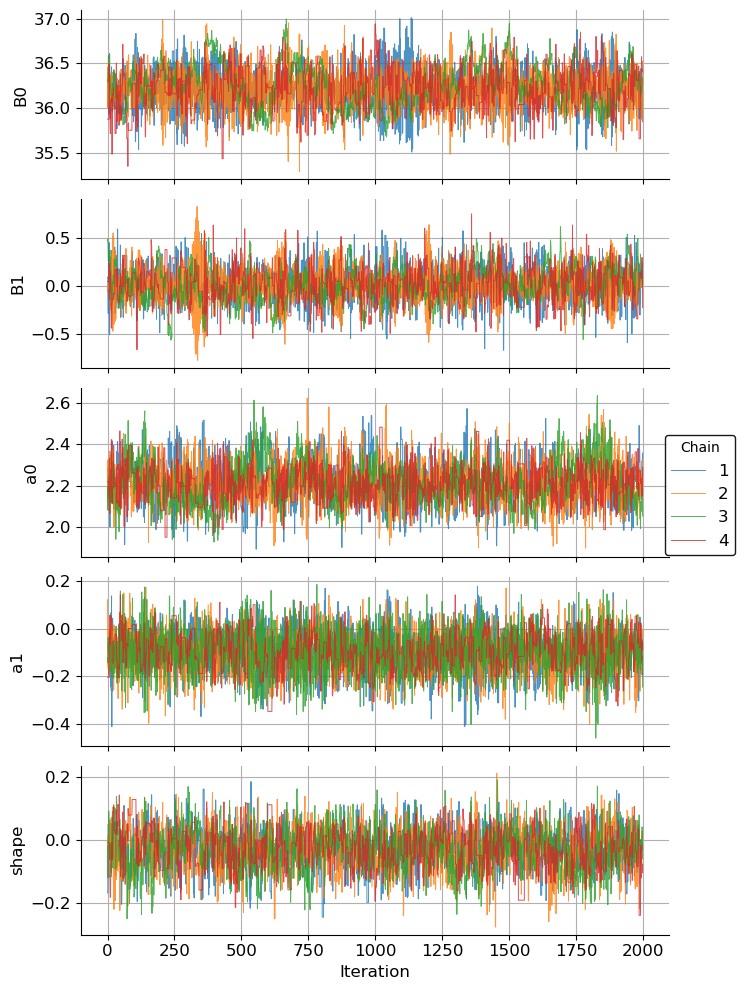

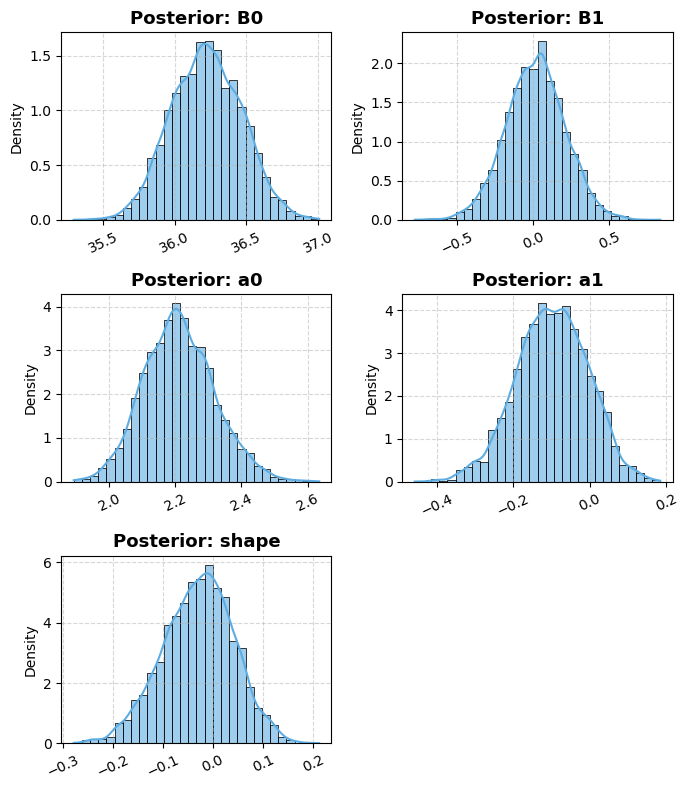

In [23]:
ns.plot_trace(samples, config, fig_size=(7, 10))
ns.plot_posterior(samples, config, fig_size=(7, 8));

## Nonstationary design-life risk and return period

For threshold `z`, `p_t = 1 - F_t(z)`. Design-life reliability is `Rel(n) = prod_t(1-p_t)` and risk is `1-Rel(n)`, the probability of at least one exceedance during `n` years. The first-exceedance PMF is `P(X=x) = p_x prod_{t<x}(1-p_t)`. The Salas & Obeysekera (2014) return period is expected waiting time `E(X)`, distinct from a time-varying return level `z_T(t)` computed separately at each time. This example uses the fitted posterior mean; posterior draws can be passed through the same methods to quantify uncertainty.


In [25]:
# Use the posterior mean and the observed covariate trajectory for a 50-year design life.
threshold = float(np.quantile(data, 0.99))
horizon = len(data)
params = sample_mean
posterior_draws = sample_all_chains[::10]

parameter_paths = sampler.predict_params(params=params, covariates=cov_scaled)
risk = sampler.nonstationary_risk(threshold, horizon, params=params,
                                   covariates=cov_scaled, posterior_samples=posterior_draws)
reliability = sampler.nonstationary_reliability(threshold, horizon,
                                                params=params,
                                                covariates=cov_scaled, posterior_samples=posterior_draws)
pmf = sampler.first_exceedance_pmf(threshold, horizon, params=params,
                                   covariates=cov_scaled, posterior_samples=posterior_draws)
return_period = sampler.nonstationary_return_period(
    threshold, horizon=horizon, params=params, covariates=cov_scaled, posterior_samples=posterior_draws
)

print(f"Threshold: {threshold:.2f} mm")
print(f"Design-life risk: {risk['risk']:.3f}")
print(f"Design-life reliability: {reliability['reliability']:.3f}")
print(f"Expected first exceedance: {return_period['return_period']:.2f} years")
print(f"PMF mass within horizon: {pmf['pmf'].sum():.3f}")

print(f"Risk 90% credible interval: {risk['uncertainty']['risk']['lower']:.3f} - {risk['uncertainty']['risk']['upper']:.3f}")
print(f"Return-period 90% credible interval: {return_period['uncertainty']['return_period']['lower']:.2f} - {return_period['uncertainty']['return_period']['upper']:.2f} years")


Threshold: 78.79 mm
Design-life risk: 0.491
Design-life reliability: 0.509
Expected first exceedance: 34.48 years
PMF mass within horizon: 0.491
Risk 90% credible interval: 0.156 - 0.836
Return-period 90% credible interval: 20.28 - 46.02 years


### Time-varying return levels

The following helper plots `z_T(t)`, while the Salas & Obeysekera return period above summarizes the waiting time to the first exceedance.

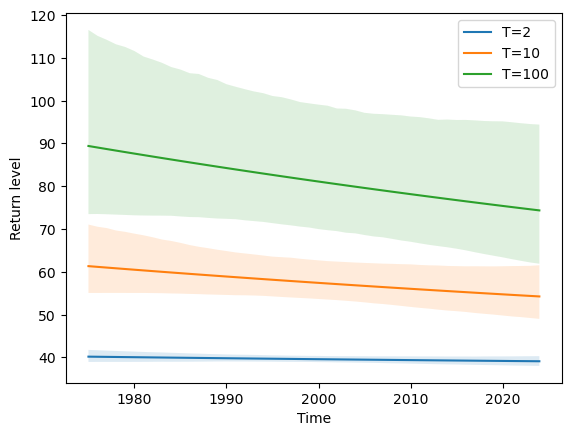

In [26]:
return_level_plot = sampler.plot_return_levels(
    return_periods=(2, 10, 100),
    params=params, covariates=cov_scaled, time=df["year"].to_numpy(), posterior_samples=posterior_draws
)
plt.show()
